In [1]:
import pickle
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from copy import deepcopy
import seaborn as sns
import cmasher
from termcolor import colored
sns.set_style('whitegrid')

# Lower opacity of grid lines
plt.rcParams['grid.alpha'] = 0.2

In [29]:
# --- Loading ICL results with 5 demos ---
demos_df = []
root = Path('/mnt/home/akirsanov/ceph/LLM_Geometry/DATA/ICL_stability/results/claude_multitask/llama3.1_base/emotion/demos/')
for p in root.glob('Category:*_examples/run_*/capacity_emotion.pickle'):
    with open(p, 'rb') as f:
        data = pickle.load(f)
        demos_df.append(data)
demos_df = pd.concat(demos_df)

# --- Raw and instruction ---
raw_df = pickle.load(open('/mnt/home/akirsanov/ceph/LLM_Geometry/DATA/ICL_stability/results/claude_multitask/llama3.1_base/emotion/raw/Category:None_examples/run_0/capacity_emotion.pickle', 'rb'))

instruction_df = pickle.load(open('/mnt/home/akirsanov/ceph/LLM_Geometry/DATA/ICL_stability/results/claude_multitask/llama3.1_base/emotion/instruction/Category:None_examples/run_0/capacity_emotion.pickle', 'rb'))


# --- Filtering by token type
token_type = 'last_token'
demos_df = demos_df.query(f"token_type == '{token_type}'")
raw_df = raw_df.query(f"token_type == '{token_type}'")
instruction_df = instruction_df.query(f"token_type == '{token_type}'")

last_layer = demos_df.layer.max()
instruction_color='#4a4a4a'

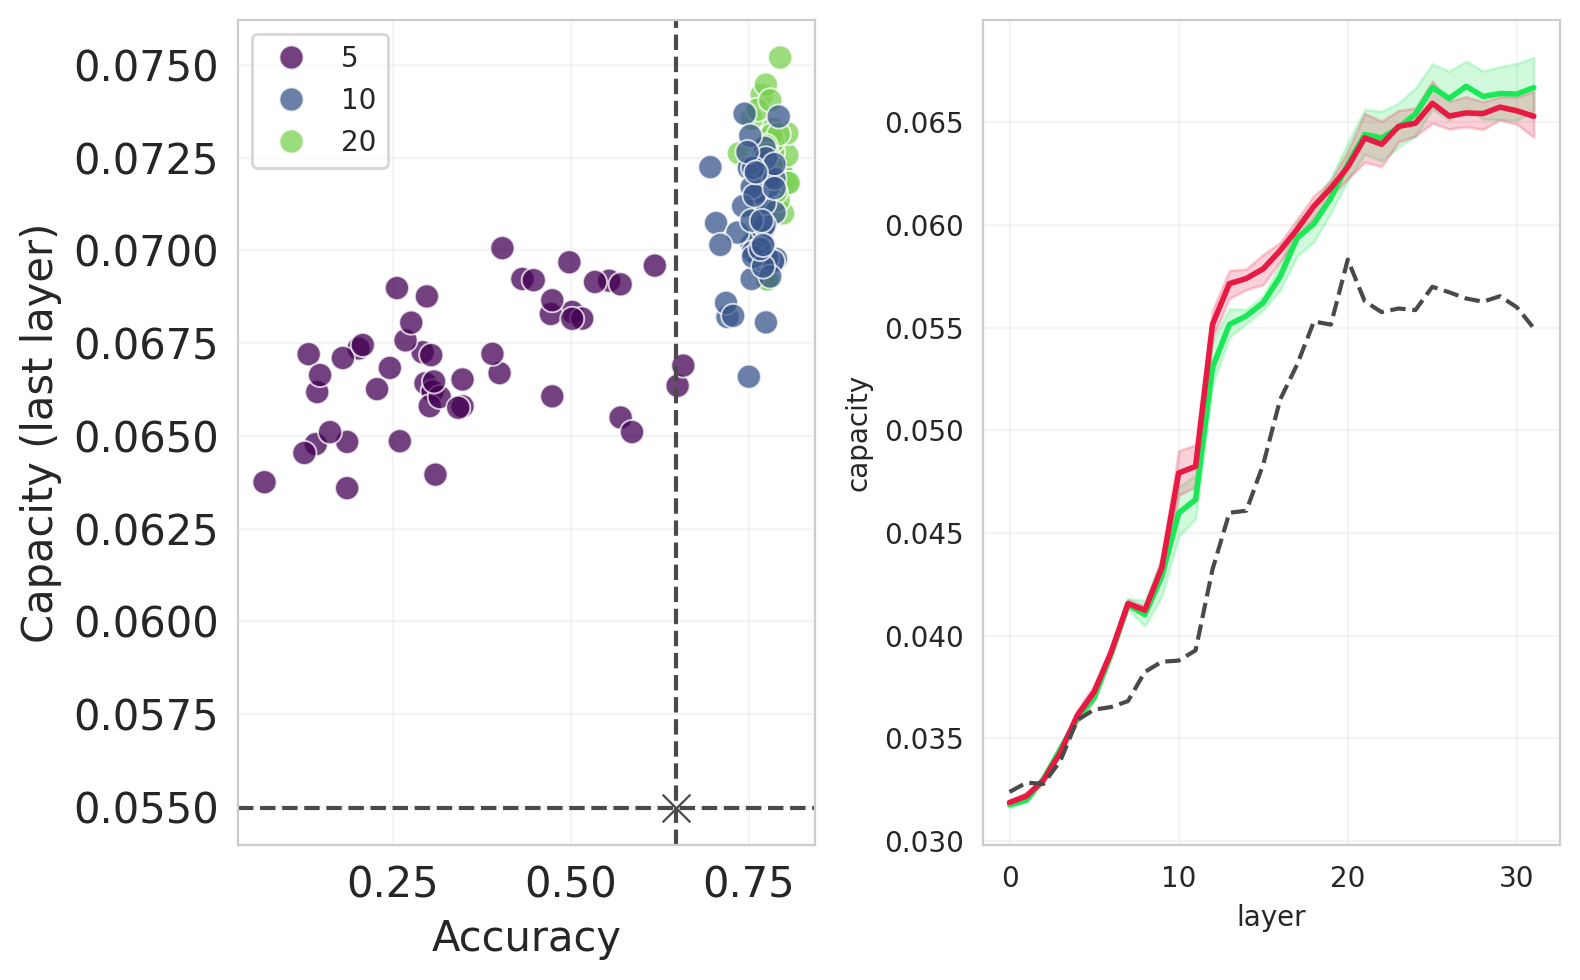

In [39]:
fig, axs = plt.subplots(1,2,figsize=(8,5), dpi=200)


ax = axs[0]
x_var, y_var = 'accuracy', 'capacity'
cmap = cmasher.get_sub_cmap(plt.cm.viridis, 0, 0.8)  
sns.scatterplot(data=demos_df.query(f"layer == {last_layer}"), x=x_var, y=y_var, s=75, hue='n_examples',  palette=cmap, ax=ax, alpha=0.75)
sns.scatterplot(data=instruction_df.query(f"layer == {last_layer}"), x=x_var, y=y_var, color = instruction_color, marker='x', ax=ax, s=100)
ax.axhline(instruction_df.query(f"layer == {last_layer}")[y_var].values[0], color=instruction_color, linestyle='--', label='Instruction')
ax.axvline(instruction_df.query(f"layer == {last_layer}")[x_var].values[0], color=instruction_color, linestyle='--')

ax.set_xlabel('Accuracy', fontsize=15)
ax.set_ylabel('Capacity (last layer)', fontsize=15)
ax.tick_params(axis='both', which='major', labelsize=15)


# --- Plot 1 (layerwise profile for 5 examples)
ax = axs[1]

sub_df = demos_df.query('n_examples == 5')
best_paths = sub_df.groupby('path')['accuracy'].max().sort_values(ascending=False).head(5)
best_df = sub_df[sub_df['path'].isin(best_paths.index)]

worst_paths = sub_df.groupby('path')['accuracy'].max().sort_values(ascending=True).head(5)
worst_df = sub_df[sub_df['path'].isin(worst_paths.index)]



sns.lineplot(data=best_df, x='layer', y='capacity', color='#149c3d', lw=2, ax=ax)
sns.lineplot(data=worst_df, x='layer', y='capacity', color='#e81a43', lw=2, ax=ax)
sns.lineplot(data=instruction_df, x='layer', y='capacity', color=instruction_color, linestyle='--', lw=1.5, ax=ax)


fig.tight_layout()